# Order Parameters

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## Load and inspect data

In [2]:
DATA_DIR = "data/order_parameters"

order_parameters = pd.read_parquet(
    f"{DATA_DIR}/order_parameters.parquet"
)

order_parameters.head()

,N,reference_N,actual_N,rho,actual_rho,seed,step,initial_fraction_elongated,force,nematic,polar,nematic_2,polar_2,fraction_elongated
0,10000,10152,9000,0.8,0.799975,12944511869278,0,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.000000,0.000000,0.000000,0.000000,0.000000
1,10000,10152,9000,0.8,0.799975,12944511869278,100,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.085179,0.097603,0.000303,0.000347,0.003556
2,10000,10152,9000,0.8,0.799975,12944511869278,200,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.087203,0.111714,0.000484,0.000621,0.005556
3,10000,10152,9000,0.8,0.799975,12944511869278,300,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.083131,0.052225,0.000693,0.000435,0.008333
4,10000,10152,9000,0.8,0.799975,12944511869278,400,0.0,Anisotropic_Grosmann_k=3.33_gamma=3_With_Noise...,0.067126,0.066713,0.000850,0.000845,0.012667


In [3]:
print("Shape:", order_parameters.shape)

print("\nColumns:")
print(order_parameters.columns.tolist())

print("\nDtypes:")
print(order_parameters.dtypes)

Shape: (128256, 14)

Columns:
['N', 'reference_N', 'actual_N', 'rho', 'actual_rho', 'seed', 'step', 'initial_fraction_elongated', 'force', 'nematic', 'polar', 'nematic_2', 'polar_2', 'fraction_elongated']

Dtypes:
N                               int64
reference_N                     int64
actual_N                        int64
rho                           float64
actual_rho                    float64
seed                            int64
step                            int64
initial_fraction_elongated    float64
force                             str
nematic                       float64
polar                         float64
nematic_2                     float64
polar_2                       float64
fraction_elongated            float64
dtype: object


In [4]:
print("N values:")
print(sorted(order_parameters["N"].unique()))

print("\nrho values:")
print(sorted(order_parameters["rho"].unique()))

print("\nNumber of seeds by rho:")
display(
    order_parameters
    .groupby("rho")["seed"]
    .nunique()
    .to_frame("n_seeds")
)

N values:
[np.int64(10000)]

rho values:
[np.float64(0.8), np.float64(0.81), np.float64(0.82), np.float64(0.83), np.float64(0.84), np.float64(0.85), np.float64(0.86), np.float64(0.87)]

Number of seeds by rho:


,n_seeds
rho,
0.80,32
0.81,32
0.82,32
0.83,32
0.84,32
0.85,32
0.86,32
0.87,32


In [5]:
print("Step range:")
print(
    "min =", order_parameters["step"].min(),
    "max =", order_parameters["step"].max(),
)

print(
    "number of unique steps =",
    order_parameters["step"].nunique(),
)

print("\nFirst steps:")
print(
    sorted(order_parameters["step"].unique())[:20]
)

Step range:
min = 0 max = 50000
number of unique steps = 501

First steps:
[np.int64(0), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1100), np.int64(1200), np.int64(1300), np.int64(1400), np.int64(1500), np.int64(1600), np.int64(1700), np.int64(1800), np.int64(1900)]


In [6]:
coverage = (
    order_parameters
    .groupby(["rho", "seed"])["step"]
    .agg(["min", "max", "nunique"])
)

display(
    coverage
    .groupby("rho")
    .agg(["min", "max"])
)

min        max        nunique     
     min max    min    max     min  max
rho                                    
0.80   0   0  50000  50000     501  501
0.81   0   0  50000  50000     501  501
0.82   0   0  50000  50000     501  501
0.83   0   0  50000  50000     501  501
0.84   0   0  50000  50000     501  501
0.85   0   0  50000  50000     501  501
0.86   0   0  50000  50000     501  501
0.87   0   0  50000  50000     501  501

In [7]:
n_duplicates = order_parameters.duplicated(
    ["N", "rho", "seed", "step"]
).sum()

print("Duplicated (N, rho, seed, step):", n_duplicates)

Duplicated (N, rho, seed, step): 0


In [8]:
display(
    order_parameters.isna().sum().to_frame("n_nan")
)

,n_nan
N,0
reference_N,0
actual_N,0
rho,0
actual_rho,0
seed,0
step,0
initial_fraction_elongated,0
force,0
nematic,0


In [9]:
polar_identity = np.allclose(
    order_parameters["polar_2"],
    order_parameters["fraction_elongated"]
    * order_parameters["polar"],
    equal_nan=True,
)

nematic_identity = np.allclose(
    order_parameters["nematic_2"],
    order_parameters["fraction_elongated"]
    * order_parameters["nematic"],
    equal_nan=True,
)

print("polar_2 = f_E * polar:", polar_identity)
print("nematic_2 = f_E * nematic:", nematic_identity)

polar_2 = f_E * polar: True
nematic_2 = f_E * nematic: True


In [10]:
op = order_parameters.copy()

op["f_E"] = op["fraction_elongated"]

op["P_E_elongated"] = op["polar"]
op["Q_E_elongated"] = op["nematic"]

op["P_E_total"] = op["polar_2"]
op["Q_E_total"] = op["nematic_2"]

## Time Series

In [11]:
# Average over seeds at each time
# We group by density and step, and compute the mean and standard deviation
# of the morphology and order parameters across seeds.

op_time = (
    op
    .groupby(["rho", "step"])
    .agg(
        f_E_mean=("f_E", "mean"),
        f_E_std=("f_E", "std"),

        P_E_elongated_mean=("P_E_elongated", "mean"),
        P_E_elongated_std=("P_E_elongated", "std"),

        Q_E_elongated_mean=("Q_E_elongated", "mean"),
        Q_E_elongated_std=("Q_E_elongated", "std"),

        P_E_total_mean=("P_E_total", "mean"),
        P_E_total_std=("P_E_total", "std"),

        Q_E_total_mean=("Q_E_total", "mean"),
        Q_E_total_std=("Q_E_total", "std"),
    )
    .reset_index()
)

# Show the first few rows
op_time.head()

,rho,step,f_E_mean,f_E_std,P_E_elongated_mean,P_E_elongated_std,Q_E_elongated_mean,Q_E_elongated_std,P_E_total_mean,P_E_total_std,Q_E_total_mean,Q_E_total_std
0,0.8,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.8,100,0.003663,0.000838,0.140318,0.071728,0.151277,0.085216,0.000488,0.000208,0.000528,0.000274
2,0.8,200,0.005865,0.001141,0.139416,0.094908,0.100676,0.064075,0.000785,0.000500,0.000582,0.000377
3,0.8,300,0.008431,0.001707,0.115062,0.068422,0.115743,0.047180,0.000946,0.000580,0.000955,0.000423
4,0.8,400,0.011962,0.002575,0.103845,0.055198,0.093661,0.052614,0.001197,0.000605,0.001053,0.000485


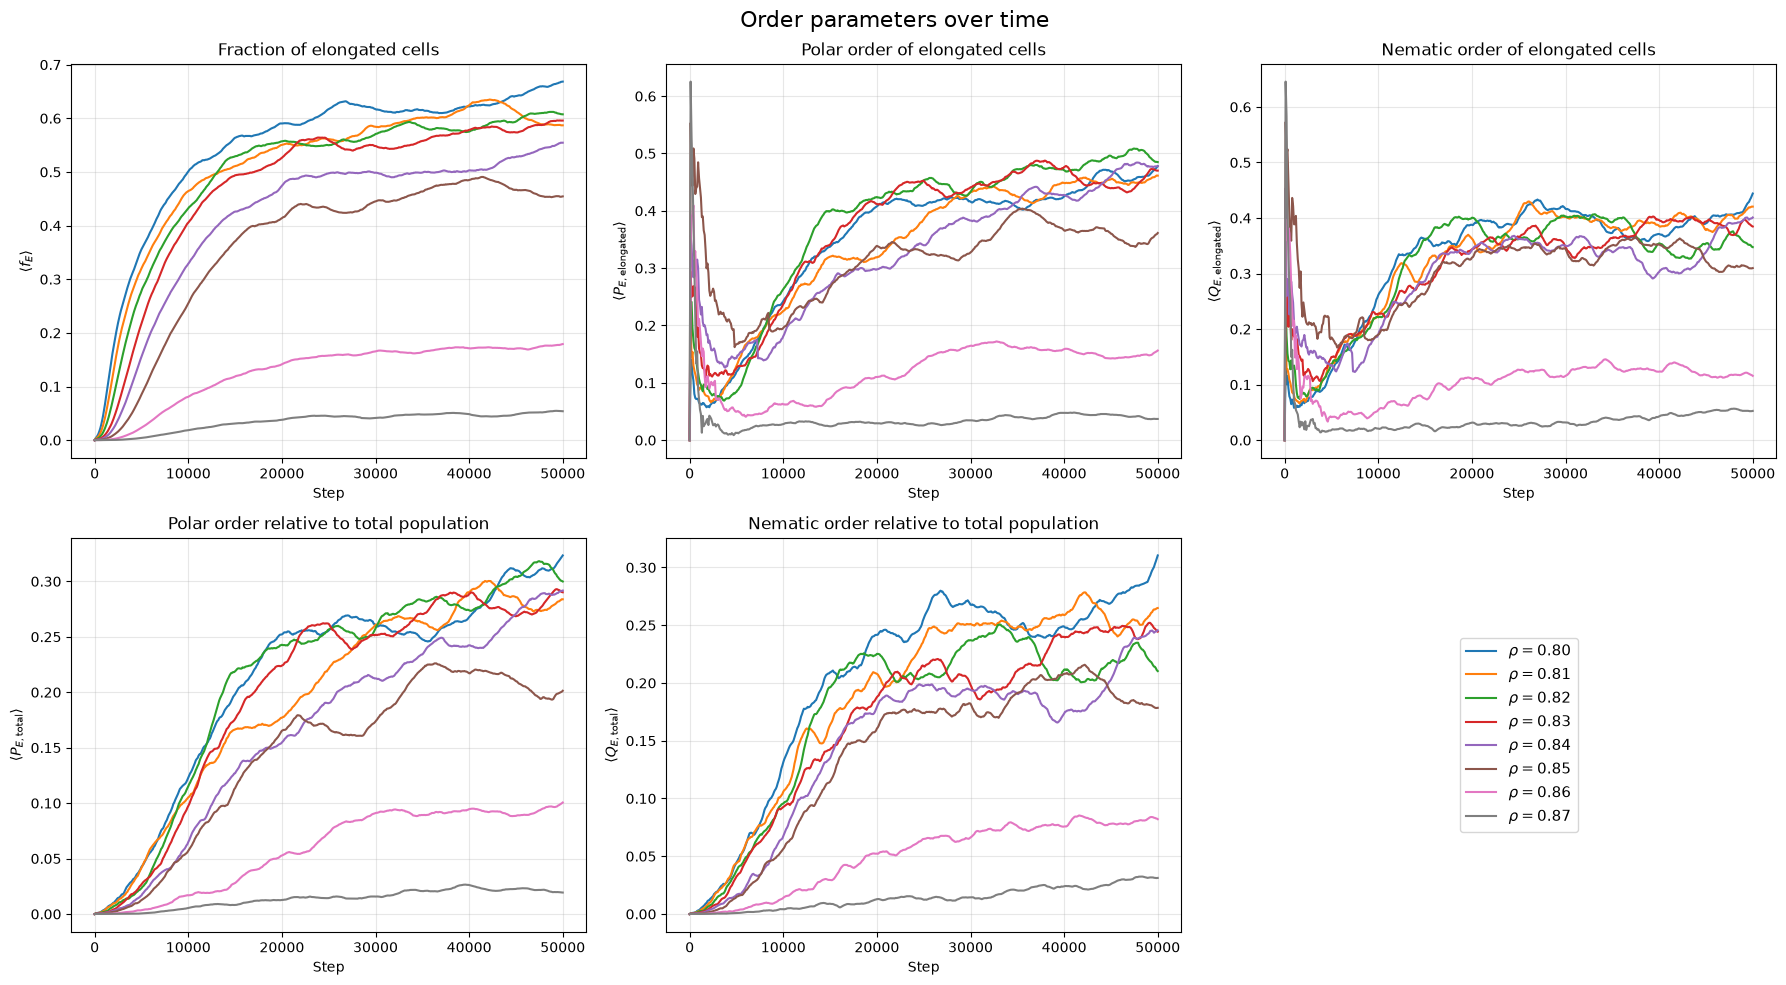

In [12]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

observables = [
    ("f_E_mean", r"$\langle f_E \rangle$", "Fraction of elongated cells"),
    (
        "P_E_elongated_mean",
        r"$\langle P_{E,\mathrm{elongated}} \rangle$",
        "Polar order of elongated cells",
    ),
    (
        "Q_E_elongated_mean",
        r"$\langle Q_{E,\mathrm{elongated}} \rangle$",
        "Nematic order of elongated cells",
    ),
    (
        "P_E_total_mean",
        r"$\langle P_{E,\mathrm{total}} \rangle$",
        "Polar order relative to total population",
    ),
    (
        "Q_E_total_mean",
        r"$\langle Q_{E,\mathrm{total}} \rangle$",
        "Nematic order relative to total population",
    ),
]

axs = axs.flatten()

for ax, (column, ylabel, title) in zip(axs, observables):

    for rho, df_rho in op_time.groupby("rho"):

        ax.plot(
            df_rho["step"],
            df_rho[column],
            label=fr"$\rho={rho:.2f}$"
        )

    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)

    # ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.grid(alpha=0.3)

# The sixth panel is not used
axs[-1].axis("off")

# Put the legend in the empty panel
handles, labels = axs[0].get_legend_handles_labels()

axs[-1].legend(
    handles,
    labels,
    loc="center",
    fontsize=11,
)

graph_title = "Order parameters over time"

fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/order_parameters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()